In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\varad\Downloads\Automated-Transaction-ETL-Pipeline\data\raw\upi_transactions_2024.csv")
df.head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   transaction id      250000 non-null  object
 1   timestamp           250000 non-null  object
 2   transaction type    250000 non-null  object
 3   merchant_category   250000 non-null  object
 4   amount (INR)        250000 non-null  int64 
 5   transaction_status  250000 non-null  object
 6   sender_age_group    250000 non-null  object
 7   receiver_age_group  250000 non-null  object
 8   sender_state        250000 non-null  object
 9   sender_bank         250000 non-null  object
 10  receiver_bank       250000 non-null  object
 11  device_type         250000 non-null  object
 12  network_type        250000 non-null  object
 13  fraud_flag          250000 non-null  int64 
 14  hour_of_day         250000 non-null  int64 
 15  day_of_week         250000 non-null  object
 16  is

In [11]:
df.duplicated().sum()
print(df.shape)
print(df.isnull().sum())

(250000, 17)
transaction id        0
timestamp             0
transaction type      0
merchant_category     0
amount (INR)          0
transaction_status    0
sender_age_group      0
receiver_age_group    0
sender_state          0
sender_bank           0
receiver_bank         0
device_type           0
network_type          0
fraud_flag            0
hour_of_day           0
day_of_week           0
is_weekend            0
dtype: int64


In [13]:
print(df['merchant_category'].value_counts())
print(df['transaction_status'].value_counts())
print(df["transaction type"].value_counts())
print(df["device_type"].value_counts())
print(df["network_type"].value_counts())
print(df["fraud_flag"].value_counts())


merchant_category
Grocery          49966
Food             37464
Shopping         29872
Fuel             25063
Other            24828
Utilities        22338
Transport        20105
Entertainment    20103
Healthcare       12663
Education         7598
Name: count, dtype: int64
transaction_status
SUCCESS    237624
FAILED      12376
Name: count, dtype: int64
transaction type
P2P             112445
P2M              87660
Bill Payment     37368
Recharge         12527
Name: count, dtype: int64
device_type
Android    187777
iOS         49613
Web         12610
Name: count, dtype: int64
network_type
4G      149813
5G       62582
WiFi     25134
3G       12471
Name: count, dtype: int64
fraud_flag
0    249520
1       480
Name: count, dtype: int64


In [12]:
df.describe()

,amount (INR),fraud_flag,hour_of_day,is_weekend
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,1311.756036,0.001920,14.681032,0.285348
std,1848.059224,0.043776,5.188304,0.451581
min,10.000000,0.000000,0.000000,0.000000
25%,288.000000,0.000000,11.000000,0.000000
50%,629.000000,0.000000,15.000000,0.000000
75%,1596.000000,0.000000,19.000000,1.000000
max,42099.000000,1.000000,23.000000,1.000000


In [22]:
df["sender_bank"].value_counts()

sender_bank
SBI         62693
HDFC        37485
ICICI       29769
IndusInd    25173
Axis        25042
PNB         24946
Yes Bank    24860
Kotak       20032
Name: count, dtype: int64

In [23]:
df["receiver_bank"].value_counts()

receiver_bank
SBI         62378
HDFC        37651
ICICI       29944
IndusInd    25086
Yes Bank    25009
Axis        24992
PNB         24802
Kotak       20138
Name: count, dtype: int64

In [15]:
# Create a copy so original dataframe remains unchanged
df_transformed = df.copy()

In [16]:
df_transformed["timestamp"] = pd.to_datetime(df_transformed["timestamp"])
print(df_transformed["timestamp"].dtype)
df_transformed["transaction_date"] = df_transformed["timestamp"].dt.date
df_transformed["transaction_month"] = (
    df_transformed["timestamp"].dt.to_period("M").astype(str)
)
df_transformed["transaction_quarter"] = (
    "Q" + df_transformed["timestamp"].dt.quarter.astype(str)
)
bins = [0, 500, 1000, 5000, 10000, float("inf")]

labels = [
    "Micro Transaction",
    "Small Transaction",
    "Medium Transaction",
    "Large Transaction",
    "Premium Transaction"
]

df_transformed["amount_bucket"] = pd.cut(
    df_transformed["amount (INR)"],
    bins=bins,
    labels=labels
)
print(df_transformed["amount_bucket"].value_counts())
df_transformed["fraud_status"] = (
    df_transformed["fraud_flag"]
    .map({0: "Genuine", 1: "Fraud"})
)
print(df_transformed["fraud_status"].value_counts())
df_transformed["transaction_outcome"] = (
    df_transformed["transaction_status"]
    .map({
        "SUCCESS": "Successful",
        "FAILED": "Failed"
    })
)
print(df_transformed["transaction_outcome"].value_counts())


datetime64[ns]
amount_bucket
Micro Transaction      106624
Medium Transaction      81383
Small Transaction       51037
Large Transaction        9151
Premium Transaction      1805
Name: count, dtype: int64
fraud_status
Genuine    249520
Fraud         480
Name: count, dtype: int64
transaction_outcome
Successful    237624
Failed         12376
Name: count, dtype: int64


In [17]:
df_transformed.columns
# df_transformed.head()

Index(['transaction id', 'timestamp', 'transaction type', 'merchant_category',
       'amount (INR)', 'transaction_status', 'sender_age_group',
       'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank',
       'device_type', 'network_type', 'fraud_flag', 'hour_of_day',
       'day_of_week', 'is_weekend', 'transaction_date', 'transaction_month',
       'transaction_quarter', 'amount_bucket', 'fraud_status',
       'transaction_outcome'],
      dtype='object')

In [18]:
df_transformed["week_type"] = (
    df_transformed["is_weekend"]
    .map({
        0: "Weekday",
        1: "Weekend"
    })
)

In [19]:
print(df_transformed.shape)
df_transformed.head()

(250000, 24)


,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,...,hour_of_day,day_of_week,is_weekend,transaction_date,transaction_month,transaction_quarter,amount_bucket,fraud_status,transaction_outcome,week_type
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,...,15,Tuesday,0,2024-10-08,2024-10,Q4,Small Transaction,Genuine,Successful,Weekday
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,...,6,Thursday,0,2024-04-11,2024-04,Q2,Medium Transaction,Genuine,Successful,Weekday
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,...,13,Tuesday,0,2024-04-02,2024-04,Q2,Micro Transaction,Genuine,Successful,Weekday
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,...,10,Sunday,1,2024-01-07,2024-01,Q1,Medium Transaction,Genuine,Successful,Weekend
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,...,19,Tuesday,0,2024-01-23,2024-01,Q1,Small Transaction,Genuine,Successful,Weekday


In [20]:
overall_fraud_rate = df_transformed['fraud_flag'].mean() * 100
print(f"Overall Fraud Rate: {overall_fraud_rate:.3f}%")

Overall Fraud Rate: 0.192%


In [21]:
fraud_by_device = df_transformed.groupby('device_type')['fraud_flag'].mean().sort_values(ascending=False) * 100
print(fraud_by_device)

device_type
Web        0.206186
Android    0.193847
iOS        0.181404
Name: fraud_flag, dtype: float64


In [22]:
fraud_by_network = df_transformed.groupby('network_type')['fraud_flag'].mean().sort_values(ascending=False) * 100
print(fraud_by_network)

network_type
WiFi    0.234742
3G      0.192446
4G      0.188235
5G      0.183759
Name: fraud_flag, dtype: float64


In [23]:
fraud_by_type = df_transformed.groupby('transaction type')['fraud_flag'].mean().sort_values(ascending=False) * 100
print(fraud_by_type)

transaction type
Recharge        0.239483
Bill Payment    0.206059
P2M             0.190509
P2P             0.183201
Name: fraud_flag, dtype: float64


In [24]:
fraud_by_week = df_transformed.groupby('week_type')['fraud_flag'].mean().sort_values(ascending=False) * 100
print(fraud_by_week)

week_type
Weekend    0.200457
Weekday    0.188623
Name: fraud_flag, dtype: float64


In [25]:
fraud_by_state = df_transformed.groupby('sender_state')['fraud_flag'].mean().sort_values(ascending=False) * 100
print(fraud_by_state)

sender_state
Karnataka         0.231886
Rajasthan         0.230219
Gujarat           0.214346
Delhi             0.201045
Maharashtra       0.189703
West Bengal       0.175245
Andhra Pradesh    0.174948
Telangana         0.173836
Uttar Pradesh     0.172614
Tamil Nadu        0.157685
Name: fraud_flag, dtype: float64


In [26]:
fraud_by_hour = df_transformed.groupby('hour_of_day')['fraud_flag'].mean().sort_values(ascending=False) * 100
print(fraud_by_hour)

hour_of_day
3     0.304414
1     0.267380
15    0.253485
22    0.245622
0     0.236128
7     0.230906
16    0.221555
8     0.215595
21    0.215345
19    0.202524
17    0.201745
20    0.199935
9     0.191388
14    0.183054
2     0.178042
12    0.171272
13    0.166246
11    0.165360
23    0.154719
18    0.154506
10    0.143843
6     0.142816
4     0.080192
5     0.057405
Name: fraud_flag, dtype: float64


In [27]:
fraud_by_month = df_transformed.groupby('transaction_month')['fraud_flag'].mean().sort_index() * 100
print(fraud_by_month)

transaction_month
2024-01    0.235616
2024-02    0.172073
2024-03    0.221343
2024-04    0.160693
2024-05    0.173440
2024-06    0.145433
2024-07    0.245202
2024-08    0.155433
2024-09    0.203913
2024-10    0.211745
2024-11    0.191496
2024-12    0.184144
Name: fraud_flag, dtype: float64


In [28]:
def time_band(hour):
    if 0 <= hour < 5:
        return "Late Night (12AM-5AM)"
    elif 5 <= hour < 12:
        return "Morning (5AM-12PM)"
    elif 12 <= hour < 17:
        return "Afternoon (12PM-5PM)"
    elif 17 <= hour < 21:
        return "Evening (5PM-9PM)"
    else:
        return "Night (9PM-12AM)"

df_transformed['time_band'] = df_transformed['hour_of_day'].apply(time_band)

fraud_by_band = df_transformed.groupby('time_band')['fraud_flag'].mean().sort_values(ascending=False) * 100
print(fraud_by_band)

time_band
Late Night (12AM-5AM)    0.222717
Night (9PM-12AM)         0.213145
Afternoon (12PM-5PM)     0.196767
Evening (5PM-9PM)        0.189399
Morning (5AM-12PM)       0.173611
Name: fraud_flag, dtype: float64


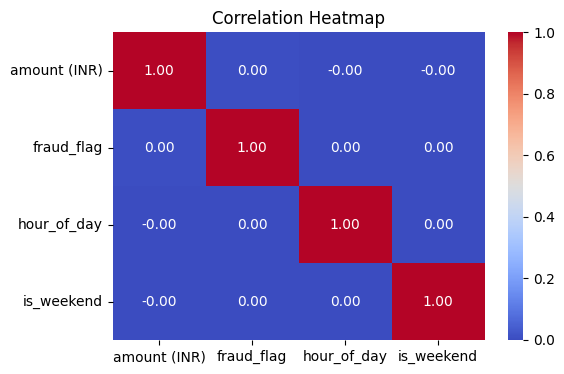

fraud_flag      1.000000
amount (INR)    0.004449
hour_of_day     0.001323
is_weekend      0.001221
Name: fraud_flag, dtype: float64


In [29]:
numeric_cols = ['amount (INR)', 'fraud_flag', 'hour_of_day', 'is_weekend']
corr = df_transformed[numeric_cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

print(corr['fraud_flag'].sort_values(ascending=False))

NameError: name 'fraud_flag' is not defined